# Pandas 1

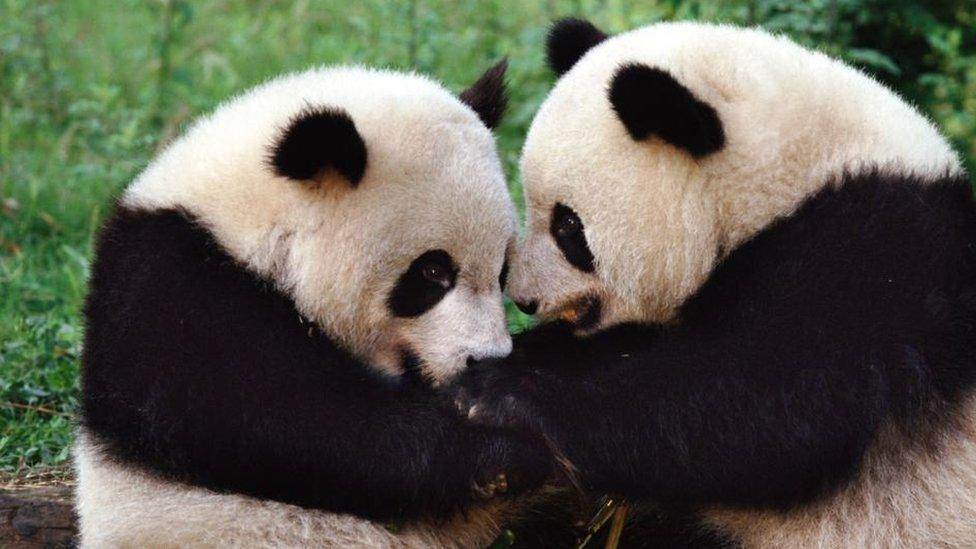

En el libro Exploratory Data Analysis (1977), John Tukey discute que los objetivos de este son:

- Facilitar descubrimientos inesperados en los datos.  
- Sugerir hipótesis sobre las causas de los fenómenos observados. 
- Evaluar los supuestos en los que se basará la inferencia estadística. 
- Respaldar la selección de herramientas y técnicas estadísticas adecuadas. 
- Proporcionar una base para la recopilación adicional de datos mediante encuestas o experimentos.  

¿Cómo se enmarca Pandas en esto? 



### Indice
- [Introdución](#intro)
    - [Importar pandas](#impa)
    - [El Objeto DataFrame](#objdf)
- [Creando Dataframes](#crea)
- [Leyendo Dataframes](#readi)
- [Desafíos comunes con archivos de datos](#desafio)
- [Trabajando con datos](#trabajando)
    - [Exploración inicial](#exploracion)
    - [Cómo seleccionar datos](#select)
    - [Filtrando información](#filter)


<a class="anchor" id="intro"></a> 
## Introducción 

_Previo: Tipos de datos._ 

Al 2026, Python tiene una serie de librerías que manejan bases de datos tabulares <sup>1</sup>. 

[Pandas](https://pandas.pydata.org/docs/getting_started/index.html) es la librería más popular de Python para realizar análisis de datos. Esta se especializa en trabajar con ciertos tipos de datos. Los más importantes son:

- Data tabular, como los dataframes (o cualquier base de datos estructurada que tengamos).
- Series (columna de data tabular)
- Series de tiempo

Los objetos de Pandas más importantes son 2: 
- Series
- Dataframes (nuestro enfoque principal). 

<sup>1</sup> Recientemente, la discusión ha virado a mejores métodos para tratar big data. Paquetes como dask, y tipos de archivos binarios como parquet, son un punto inicial. Lo importante es lo siguiente: Son extensiones de Pandas! :)



<a class="anchor" id="impa"></a> 

### 1. Importar pandas

In [ ]:
import pandas as pd

: 

<a class="anchor" id="objdf"></a> 

### 2. El objeto dataframe

- Casi siempre trabajaremos con dataframes. 

Pero qué es un dataframe? 


- Es el **objeto** principal de pandas, el cual representa una estructura de datos de dos dimensiones: filas y columnas. 
- Cada fila es una observación o registro;  cada columna, una variable, atributo, _feature_, etc.
- Hay un sólo valor por celda.   
- El dataframe sirve para representar datos tabulares. 


Adicionalmente, todo dataframe tiene un **índice**, que funge como identificador único de cada fila. 
Las columnas no necesitan ello, porque por regla, los nombres ya son su identificador único. Por ello, no se acepta nombres repetidos de columna. 

2 maneras de usar dataframes: crearlo por nosotros mismos ó leer datos.


<img src="../img/db_example.jpeg" width="800">



<br>
</br>

<a class="anchor" id="crea"></a> 

####  Una forma simple de crear dataframes: 

- Por filas

In [ ]:
nombres = ['nombre','apellido']

obs1 = ["Carla","Solis"]
obs2 = ["Monica","Gutierrez"]

- Por columnas 

In [ ]:
df = pd.DataFrame()



### Vectorización:
La vectorización se define como aplicar una operación sobre el conjunto de elementos de un vector, en lugar de hacerlo sobre cada elemento de forma individual. 
Pandas integra dicha vectorización tal que las operaciones se realizan más rápida, fácil y eficientemente. 




In [ ]:
mivar = 5

In [ ]:
# Ejemplo de vectorización:
## Nótese: Aquí creamos un dataframe con un diccionario, donde las llaves son los nombres de las columnas y
#  los valores son listas con los valores de cada columna.
df = pd.DataFrame({'vec': [1, 2, 3, 4, 5],
                   'non_vec': [1, 2, 3, 4, 5]})

# # No vectorizado: Se utiliza un bucle para realizar la operación. no muy recomendaros para pandas 
for i in range(len(df)):
    df.at[i, 'non_vec'] += 10

# print(df)
# # Vewctorizado: Se llama al nombre de la variable como si fuera un vector.
df['vec'] = df['vec'] + 10

print(df)

##


<a class="anchor" id="readi"></a> 

#### Leyendo la información:  
Los archivos que tenemos pueden estar en distintos formatos: dta, sav, json, csv, txt. Pandas puede leer cualquiera de dichos tipos de archivos. 
Lo importante es que en esencia, todos ellos representan datos **tabulares**, o datos que tienen 


| Método de pandas según file | Tipo de archivo        | Descripción                              |
|------------------|------------------------|------------------------------------------|
| `read_csv()`     | CSV                    | Lee archivos de valores separados por comas (CSV). |
| `read_json()`    | JSON                   | Lee datos estructurados como JSON. |
| `read_stata()`   | Stata                  | Lee archivos de datos en Stata.          |
| `read_spss()`    | SPSS                   | Lee archivos de datos en SPSS.           |
| `read_excel()`   | Excel (xls, xlsx)      | Lee archivos Excel.              |
| `read_pickle()`  | Pickle                 | Lee objetos Python serializados almacenados en archivos Pickle. |
| `read_parquet()` | Parquet                | Lee archivos Parquet.         |
| `read_feather()` | Feather                | Lee archivos Feather.         |
| `read_sql()`     | SQL Query / Database   | Lee de una base de datos usando una consulta SQL. |
| `read_sas()`     | SAS                    | Lee archivos de datos de SAS.            |
| `read_hdf()`     | HDF5                   | Lee archivos HDF5.            |
| `read_orc()`     | ORC                    | Lee archivos ORC.             |
| `read_fwf()`     | Fixed-Width Formatted  | Lee archivos de texto con ancho fijo.    |

- Los métodos están organizados según importancia. 
- Hay otros métodos como `read_html`, `read_orc`, y `read_fwf`. Otros paquetes adicionales leen, por ejemplo, archivos .RData (R). 

Hoy nos enfocaremos en la base de datos de postulantes de la Universidad Nacional de Ingeniería: 
https://www.datosabiertos.gob.pe/dataset/postulantes-al-concurso-de-admisi%C3%B3n-de-la-universidad-nacional-de-ingenier%C3%ADa-uni

In [ ]:
df

<a class="anchor" id="desafio"></a> 

### Desafíos comunes con archivos de datos. 

Recibir datos de terceros va a ser muy habitual en la labor de data scientists. Algunas situaciones a tener en cuenta (para el futuro), en particular con exceles y csvs, son las siguientes:

Con CSV:
- Problemas con los delimitadores: Lo común es  que el delimitador sea la coma `,`, sin embargo,`|`,  `;` ó incluso `Tab` pueden aparecer, lo que  originará errores de lectura si no se especifica el delimitador correcto. 
- Comillas que no cierran: `"""  ""`. 
- Codificación diferente: 
    - Datos en español en una codificación anglosajona (e.g.) ocasionará caracteres extraños. 
    - Tipo de datos diferente (string en vez de numérico).
- Datos faltantes: la falta de comas puede ocasionar errores en cargar los datos. 
- Saltos de línea no sistemáticos

Con Excel:
- Datos no tabulares: Exceles que no tienen datos tabulares pueden ocasionar errores de lectura. 
- Más de un valor por celda. 
- Fórmulas de excel. 

<a class="anchor" id="trabajando"></a> 

### Trabajando con datos

<a class="anchor" id="exploracion"></a> 


### Exploración inicial 

Los siguientes son métodos/atributos de exploración que aplicamos sobre el dataframe mismo. 

| Método / Atributo         | Descripción                                                                                             |
|-----------------|---------------------------------------------------------------------------------------------------------|
| `head(n)`/`tail(n)` | Muestra las primeras/últimas n filas del DataFrame.
| `describe()`    | Da estadísticas como el promedio, desviación estándar, mínimo y máximo de **columnas numéricas**. |
| `info()`        | Nos ofrece información importante como los tipos de los atributos y sus valores nulos.     |
| `dtypes`        | Da los tipos de datos del dataframe                                             |
| `shape`         | Informa sobre la dimensión del dataframe en forma de tupla `(nfilas, ncolumnas)` |
| `columns`         | Informa sobre el nombre de las columnas del dataframe. |


In [ ]:
#df.describe()
#df.info()
#df.head()
#df.tail(4)

#df.dtypes
#df.shape
#df.columnns

Ahora exploraremos una columna en particular. Aquí se utilizará la exploración para una columna determinada (luego veremos que estas son Series). 

| Método          | Descripción                                                                                       |
|-----------------|---------------------------------------------------------------------------------------------------|
| `unique()`      | Da los valores únicos de la serie.                                                          |
| `nunique()`     | Cuenta cuántos elementos únicos hay en la serie.                                                 |
| `sort_values()` | Ordena la serie.         |
| `value_counts()`| Da distribución de frecuencias de cada valor único de la serie.                                             |


Para datos numéricos:                                                    
`sum()`, `mean()`,  `min()`, `max()`, `mode()`, `median()` ,  `std()`

Ejercicios: 
- Averigua cuáles son los 5 primeros departamentos en donde nacen los postulantes. 
- Cuenta cuántos hombres/mujeres postulan a la UNI. 
- Cuenta cuántos ingresan.  
Hint: value_counts()

In [ ]:
df.head(5)
##funcinoes Hash



: 

<a class="anchor" id="select"></a> 

### Cómo seleccionar datos

In [ ]:
df['ANIO_NACIMIENTO'].unique()
df['ANIO_NACIMIENTO'].nunique() ##numero de valores únicos
df[1:10]
df.iloc[1:10, 0:3] ##seleccionar observaciones y columnas, indices
df.loc[1:10, 0:3] ##nombres
df[['COLEGIO_DEPA','ANIO_NACIMIENTO']]


Un dataframe está compuesto de varias series (una serie es lo que conocemos como una columna). 


In [ ]:
## objetos series

type(df['ANIO_NACIMIENTO']) 


Explorando relaciones entre columnas

### Selección de datos

#### Selección de columnas 

#### Selección y filtración de filas/columnas con ``` iloc``` y ```loc ```

Primero seleccionaremos columnas, para lo que utilizaremos  ``` iloc``` y ```loc ```. 

##### Utilizando el iloc
El iloc ubica las observaciones que corresponden al índice que le indicamos. 
Recordando nuestra base de postulantes: 

In [ ]:
filas = [1,5,3000]
cols = [4,6,21]


In [ ]:
df.iloc[3:]

##### Utilizando el ```loc```

El ``` loc``` es una forma de ubicar observaciones que se basa en las etiquetas, tanto de columnas como de filas. 


<a class="anchor" id="filter"></a> 

### Filtrando información

Muchas veces querremos quedarnos con un subconjunto de datos que cumplen cierta condición. Las condiciones tienen que evaluarse a un booleano.

#### Filtrando información con condiciones

In [ ]:
condicion =[False]*(len(df)-5)+[True]*5

In [ ]:
df[condicion]

In [ ]:
condicion=df['Lima']

In [ ]:
cond_1=df['COLEGIO_DEPA'] == 'LIMA'
cond_2= df['INGRESO'] == 'NO'
df [cond_1 | cond_2]

Ejercicio: Filtra el dataframe para que solo te quedes con las observaciones que sean de Lima y que hayan ingresado.

In [ ]:
cond=df['COLEGIO_DEPA']

En general, Pandas tiene una serie de métodos para filtrar información. 
Vamos viendo cuándo aplicar cada uno: 


| Método         | Ejemplo de uso                                                                                                        |
|----------------|-----------------------------------------------------------------------------------------------------------------------|
| `loc`          | `df.loc[(df['ANIO_POSTULA'] > 2020) & (df['ANIO_NACIMIENTO'] < 2000), 'ANIO_NACIMIENTO']`    |
| `iloc`         | `df.iloc[0:5, 0:2]` Accede a las primeras 5 filas y primeras 2 columnas.                                                |
| `query`        | `df.query('(ANIO_POSTULA > 2020) & (ANIO_NACIMIENTO < 2000)')` 
| `filter`       | `df.filter(items=['ANIO_NACIMIENTO', 'ANIO_POSTULA'])`                                          |
| `where`        | `df.where((df['ANIO_POSTULA'] > 2020) & (df['ANIO_NACIMIENTO'] < 2000))` Preserva shape pero rellena con Nan     |
| `mask`         | `df.mask((df['ANIO_POSTULA'] > 2020) & (df['ANIO_NACIMIENTO'] < 2000))` Cambia a NaN los valores donde 'ANIO_POSTULA' > 2020 y 'ANIO_NACIMIENTO' < 2000.                            |
| `isin`         | `df[df['ANIO_NACIMIENTO'].isin([2000, 2001])]` 

In [ ]:
df.loc[(df['ANIO_POSTULA']>2022) & (df['ANIO_NACIMIENTO']<2002)]

## Ejercicio: 
1. Filtra el dataframe y quédate con quienes postularon a la 'ESPECIALIDAD' de INGENIERÍA MECATRÓNICA y cuyo lugar de nacimiento sea Callao. 
2. Filtra el dataframe y quédate con los postulantes cuyo país de estudio no haya sido Perú. 
3. Filtra el dataframe y quédate con los postulantes de nacieron en Cajamarca y sí ingresaron.
4. Filtra el dataframe y quédate con los postulantes que obtuvieron una calificación final mayor a 17 e ingresaron por modalidad ordinario. 
